Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Data

In [4]:
df = pd.read_csv('/content/drive/MyDrive/Thesis docs/tweet_lyrics_vad_go.csv')

df.head()

,Unnamed: 0,title,artist,disorder,sentiment_direction,sentiment_score,lyric,emotion_anger_score,emotion_disgust_score,emotion_fear_score,...,lyric_arousal,lyric_dominance,tweet_emotion_anger_score,tweet_emotion_disgust_score,tweet_emotion_fear_score,tweet_emotion_joy_score,tweet_emotion_neutral_score,tweet_emotion_sadness_score,tweet_emotion_surprise_score,tweet_top_emotion
0,0,Burnin Bridges / Long Day (feat. IDK),Quadeca,depression,POSITIVE,0.9971,Highest To Lowest: Quadeca LyricsQuadeca's Son...,0.0294,0.0014,0.0132,...,3.134274,3.088945,0.008775,0.076281,0.008152,0.017913,0.777388,0.087682,0.023809,neutral
1,1,She's A Lady,Tom Jones,control,POSITIVE,0.9988,She’s a Lady Lyrics[Verse 1]\nWell she's all y...,0.0271,0.0203,0.0071,...,3.499823,3.281325,0.004016,0.002873,0.002972,0.045880,0.883454,0.003640,0.057165,neutral
2,2,Lilies of the Valley,David Byrne,control,POSITIVE,0.9532,Lilies of the Valley Lyrics[Verse 1]\nMomma sh...,0.0252,0.0054,0.0556,...,3.451024,3.187569,0.004016,0.002873,0.002972,0.045880,0.883454,0.003640,0.057165,neutral
3,3,School's Out,Alice Cooper,control,NEGATIVE,0.9995,"School’s Out Lyrics[Verse 1]\nWell, we got no ...",0.1258,0.1330,0.0149,...,3.398807,3.123258,0.004016,0.002873,0.002972,0.045880,0.883454,0.003640,0.057165,neutral
4,4,Call My Friends,Shawn Mendes,depression,POSITIVE,0.9978,"Call My Friends Lyrics[Verse 1]\nRight now, I'...",0.0016,0.0006,0.0015,...,3.343280,3.164068,0.006954,0.002324,0.002624,0.113305,0.424361,0.099336,0.351096,neutral


Let it analyse & plot 

Per-emotion correlation (lyric score vs. matching tweet score)

In [5]:
emotions = ['anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness', 'surprise']

lyrics_cols = [f'emotion_{e}_score' for e in emotions]
tweets_cols = [f'tweet_emotion_{e}_score' for e in emotions]

corr_rows = []

for e in emotions:
    lyric_col, tweet_col = f'emotion_{e}_score', f'tweet_emotion_{e}_score'
    sub = df[[lyric_col, tweet_col]].dropna()
    corr_rows.append({
        'emotion': e,
        'pearson_r': sub[lyric_col].corr(sub[tweet_col], method='pearson'),
        'spearman_r': sub[lyric_col].corr(sub[tweet_col], method='spearman'),
        'n': len(sub)
    })

corr_df = pd.DataFrame(corr_rows).sort_values('pearson_r', ascending=False)
corr_df

,emotion,pearson_r,spearman_r,n
0,anger,0.021755,0.029075,55757
3,joy,0.018797,0.021921,55757
5,sadness,0.004151,0.011721,55757
6,surprise,0.001807,0.003131,55757
2,fear,0.000081,0.008746,55757
1,disgust,-0.000499,0.009368,55757
4,neutral,-0.006415,0.003290,55757


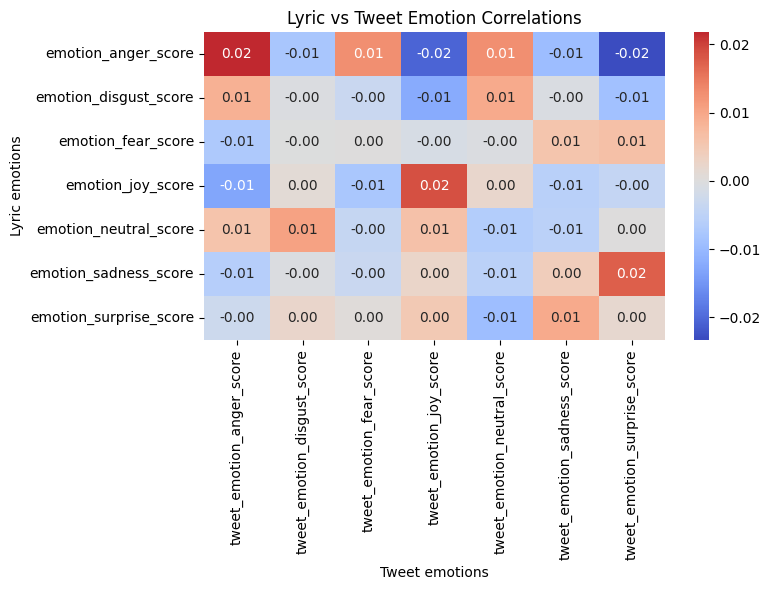

In [9]:
cross_corr = pd.DataFrame(
    {t: [df[l].corr(df[t]) for l in lyrics_cols] for t in tweets_cols},
    index=lyrics_cols,
)

plt.figure(figsize=(8, 6))
sns.heatmap(cross_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Lyric vs Tweet Emotion Correlations")
plt.xlabel("Tweet emotions")
plt.ylabel("Lyric emotions")
plt.tight_layout()
plt.show()

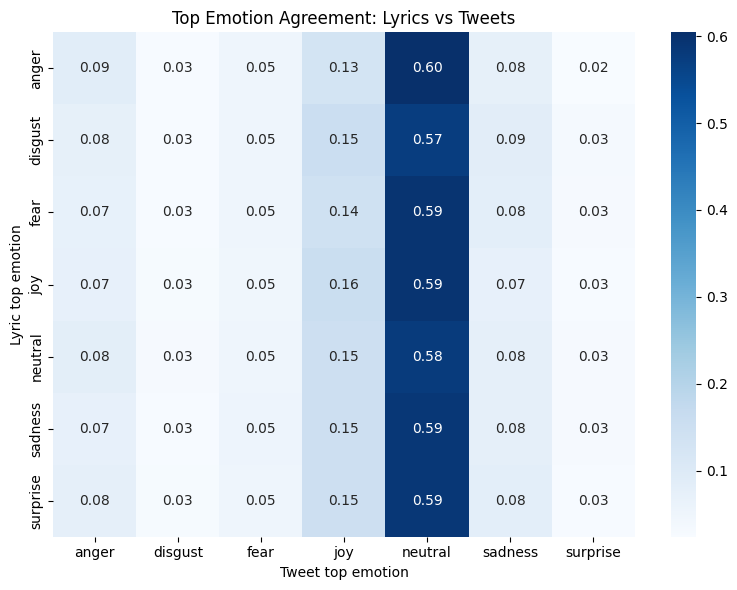

Exact top-emotion match rate: 13.71%


In [10]:
df["lyric_top_emotion"] = (
    df[lyrics_cols].idxmax(axis=1)
    .str.replace("emotion_", "", regex=False)
    .str.replace("_score", "", regex=False)
)

agreement = pd.crosstab(df["lyric_top_emotion"], df["tweet_top_emotion"], normalize="index")

plt.figure(figsize=(8, 6))
sns.heatmap(agreement, annot=True, fmt=".2f", cmap="Blues")
plt.title("Top Emotion Agreement: Lyrics vs Tweets")
plt.xlabel("Tweet top emotion")
plt.ylabel("Lyric top emotion")
plt.tight_layout()
plt.show()

exact_match_rate = (df["lyric_top_emotion"] == df["tweet_top_emotion"]).mean()
print(f"Exact top-emotion match rate: {exact_match_rate:.2%}")

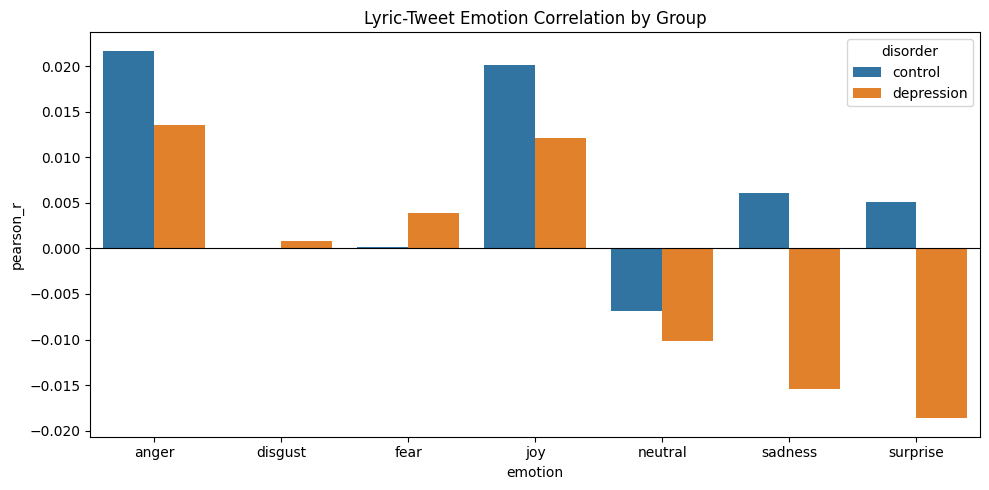

In [11]:
group_corr = []
for group, gdf in df.groupby("disorder"):
    for e in emotions:
        r = gdf[f"emotion_{e}_score"].corr(gdf[f"tweet_emotion_{e}_score"])
        group_corr.append({"disorder": group, "emotion": e, "pearson_r": r})

group_corr_df = pd.DataFrame(group_corr)

plt.figure(figsize=(10, 5))
sns.barplot(data=group_corr_df, x="emotion", y="pearson_r", hue="disorder")
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Lyric-Tweet Emotion Correlation by Group")
plt.tight_layout()
plt.show()

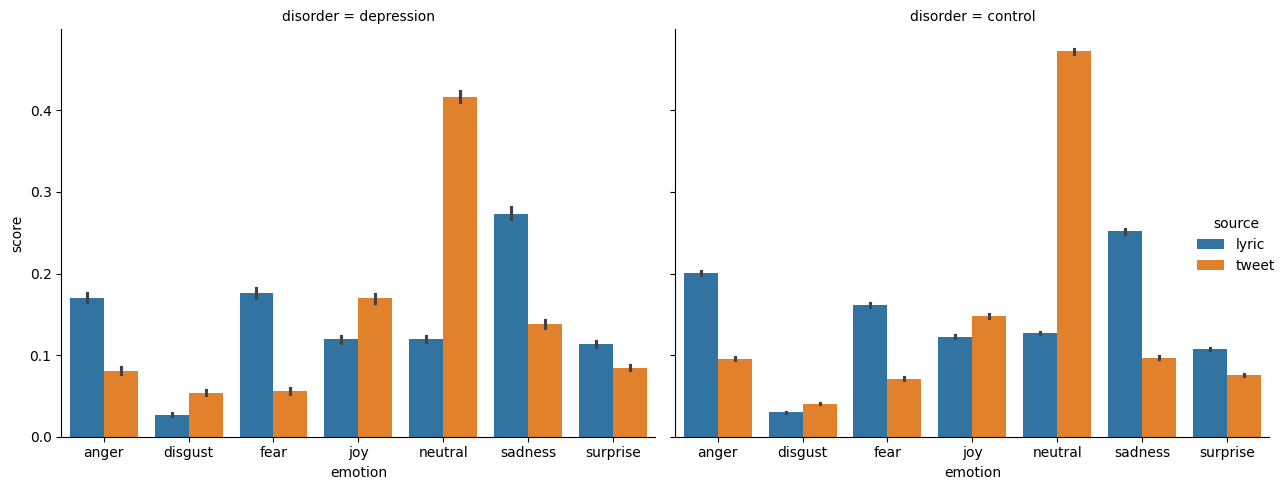

In [12]:
melted = df.melt(id_vars=["disorder"], value_vars=lyrics_cols + tweets_cols,
                  var_name="column", value_name="score")
melted["source"] = melted["column"].apply(lambda c: "tweet" if c.startswith("tweet_") else "lyric")
melted["emotion"] = (
    melted["column"].str.replace("tweet_emotion_", "", regex=False)
    .str.replace("emotion_", "", regex=False)
    .str.replace("_score", "", regex=False)
)

sns.catplot(data=melted, x="emotion", y="score", hue="source", col="disorder",
            kind="bar", height=5, aspect=1.2)
plt.tight_layout()
plt.show()

In [13]:
from scipy.stats import wilcoxon

test_rows = []
for e in emotions:
    sub = df[[f"emotion_{e}_score", f"tweet_emotion_{e}_score"]].dropna()
    stat, p = wilcoxon(sub[f"emotion_{e}_score"], sub[f"tweet_emotion_{e}_score"])
    test_rows.append({"emotion": e, "wilcoxon_stat": stat, "p_value": p, "n": len(sub)})

pd.DataFrame(test_rows)

,emotion,wilcoxon_stat,p_value,n
0,anger,452192667.5,0.000000e+00,55757
1,disgust,765004677.5,1.303545e-03,55757
2,fear,475974595.5,0.000000e+00,55757
3,joy,716478586.5,1.682764e-57,55757
4,neutral,164369645.0,0.000000e+00,55757
5,sadness,369785634.0,0.000000e+00,55757
6,surprise,678508858.0,9.992368e-149,55757


# Final checks: relationships among emotions and with VAD

These cells are appended checks; all earlier code is left unchanged. Spearman correlation is emphasized because the scores are bounded and can be skewed, while Pearson is retained for comparison. Benjamini–Hochberg FDR correction is applied within each family of tests. With this large sample, interpret effect size as well as significance: `|r| < 0.10` is treated as negligible.

> **Important:** the seven emotion scores are compositional (they compete for probability mass), so negative correlations among emotions can partly arise mechanically. These checks show association, not causation.

In [14]:
from itertools import combinations
from scipy.stats import pearsonr, spearmanr, chi2_contingency

vad_dims = ["valence", "arousal", "dominance"]
lyric_vad_cols = [f"lyric_{v}" for v in vad_dims]
tweet_vad_cols = [f"tweet_{v}" for v in vad_dims]

required_cols = lyrics_cols + tweets_cols + lyric_vad_cols + tweet_vad_cols
missing_cols = [c for c in required_cols if c not in df.columns]

if missing_cols:
    raise KeyError(f"Missing columns required for final checks: {missing_cols}")


def bh_fdr(p_values):
    """Benjamini-Hochberg adjusted p-values, preserving NaNs and input order."""
    p = np.asarray(p_values, dtype=float)
    q = np.full(p.shape, np.nan, dtype=float)

    valid = np.isfinite(p)
    if not valid.any():
        return q

    pv = p[valid]
    order = np.argsort(pv)
    ranked = pv[order]

    adjusted = ranked * len(ranked) / np.arange(1, len(ranked) + 1)
    adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]

    restored = np.empty_like(adjusted)
    restored[order] = np.minimum(adjusted, 1.0)

    q[valid] = restored
    return q


def effect_label(r):
    if pd.isna(r):
        return "undefined"

    a = abs(r)

    if a < 0.10:
        return "negligible"
    if a < 0.30:
        return "weak"
    if a < 0.50:
        return "moderate"

    return "strong"


def correlation_table(data, pair_specs):
    """Calculate Pearson and Spearman tests for a list of x/y column specifications."""
    rows = []

    for spec in pair_specs:
        x_col, y_col = spec["x"], spec["y"]

        sub = (
            data[[x_col, y_col]]
            .apply(pd.to_numeric, errors="coerce")
            .dropna()
        )

        row = {
            k: v
            for k, v in spec.items()
            if k not in {"x", "y"}
        }

        row.update({
            "x_col": x_col,
            "y_col": y_col,
            "n": len(sub),
        })

        if (
            len(sub) < 3
            or sub[x_col].nunique() < 2
            or sub[y_col].nunique() < 2
        ):
            pearson_r = pearson_p = spearman_r = spearman_p = np.nan

        else:
            pearson_r, pearson_p = pearsonr(
                sub[x_col],
                sub[y_col],
            )

            spearman_r, spearman_p = spearmanr(
                sub[x_col],
                sub[y_col],
            )

        row.update({
            "pearson_r": pearson_r,
            "pearson_p": pearson_p,
            "spearman_r": spearman_r,
            "spearman_p": spearman_p,
        })

        rows.append(row)

    result = pd.DataFrame(rows)

    if not result.empty:
        result["pearson_q"] = bh_fdr(result["pearson_p"])
        result["spearman_q"] = bh_fdr(result["spearman_p"])

        result["effect"] = result["spearman_r"].map(effect_label)

        result["fdr_significant"] = (
            result["spearman_q"] < 0.05
        )

        result["practically_meaningful"] = (
            result["spearman_r"].abs() >= 0.10
        )

    return result


print(
    f"Final checks ready: {len(df):,} rows; "
    "all required emotion and VAD columns found."
)

Final checks ready: 55,757 rows; all required emotion and VAD columns found.


## 1. Relationships among emotions

The first table checks emotion pairs within lyrics and within tweets. The second checks every lyric-emotion/tweet-emotion pairing, including both matching and non-matching emotions.

Emotion-to-emotion correlations within each source (largest |Spearman r| first):


,source,emotion_1,emotion_2,x_col,y_col,n,pearson_r,pearson_p,spearman_r,spearman_p,pearson_q,spearman_q,effect,fdr_significant,practically_meaningful
0,lyric,anger,disgust,emotion_anger_score,emotion_disgust_score,55757,0.210034,0.000000e+00,0.649188,0.000000e+00,0.000000e+00,0.000000e+00,strong,True,True
1,tweet,anger,fear,tweet_emotion_anger_score,tweet_emotion_fear_score,55757,0.048028,7.659247e-30,0.609992,0.000000e+00,8.042209e-30,0.000000e+00,strong,True,True
2,lyric,joy,neutral,emotion_joy_score,emotion_neutral_score,55757,0.062187,6.630342e-49,0.539114,0.000000e+00,7.526334e-49,0.000000e+00,strong,True,True
3,lyric,disgust,neutral,emotion_disgust_score,emotion_neutral_score,55757,0.105349,2.435127e-137,0.532671,0.000000e+00,3.526736e-137,0.000000e+00,strong,True,True
4,tweet,anger,disgust,tweet_emotion_anger_score,tweet_emotion_disgust_score,55757,0.102525,3.827961e-130,0.505669,0.000000e+00,5.359145e-130,0.000000e+00,strong,True,True
5,lyric,neutral,surprise,emotion_neutral_score,emotion_surprise_score,55757,0.010090,1.718853e-02,0.474823,0.000000e+00,1.718853e-02,0.000000e+00,moderate,True,True
6,tweet,disgust,joy,tweet_emotion_disgust_score,tweet_emotion_joy_score,55757,-0.167768,0.000000e+00,-0.340243,0.000000e+00,0.000000e+00,0.000000e+00,moderate,True,True
7,lyric,fear,sadness,emotion_fear_score,emotion_sadness_score,55757,-0.323868,0.000000e+00,-0.340008,0.000000e+00,0.000000e+00,0.000000e+00,moderate,True,True
8,lyric,joy,surprise,emotion_joy_score,emotion_surprise_score,55757,-0.057778,1.905670e-42,0.336511,0.000000e+00,2.106267e-42,0.000000e+00,moderate,True,True
9,lyric,fear,joy,emotion_fear_score,emotion_joy_score,55757,-0.247041,0.000000e+00,-0.302912,0.000000e+00,0.000000e+00,0.000000e+00,moderate,True,True


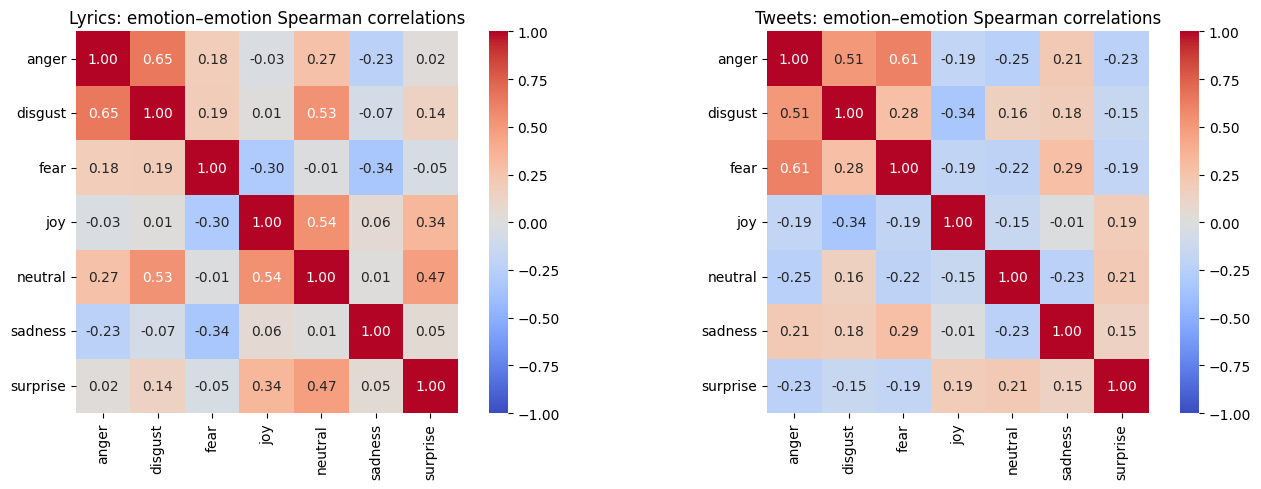

In [15]:
within_emotion_specs = []

for source, cols in [
    ("lyric", lyrics_cols),
    ("tweet", tweets_cols),
]:
    for e1, e2 in combinations(emotions, 2):
        within_emotion_specs.append({
            "x": cols[emotions.index(e1)],
            "y": cols[emotions.index(e2)],
            "source": source,
            "emotion_1": e1,
            "emotion_2": e2,
        })


within_emotion_results = correlation_table(
    df,
    within_emotion_specs,
)

print(
    "Emotion-to-emotion correlations within each source "
    "(largest |Spearman r| first):"
)

display(
    within_emotion_results
    .assign(
        abs_r=within_emotion_results["spearman_r"].abs()
    )
    .sort_values(
        "abs_r",
        ascending=False,
    )
    .drop(
        columns="abs_r",
    )
    .reset_index(
        drop=True,
    )
)


fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
)

for ax, (source, cols) in zip(
    axes,
    [
        ("Lyrics", lyrics_cols),
        ("Tweets", tweets_cols),
    ],
):
    matrix = df[cols].corr(
        method="spearman",
    )

    matrix.index = emotions
    matrix.columns = emotions

    sns.heatmap(
        matrix,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        vmin=-1,
        vmax=1,
        square=True,
        ax=ax,
    )

    ax.set_title(
        f"{source}: emotion–emotion Spearman correlations"
    )

plt.tight_layout()
plt.show()

Matching lyric–tweet emotions:


,lyric_emotion,tweet_emotion,pair_type,x_col,y_col,n,pearson_r,pearson_p,spearman_r,spearman_p,pearson_q,spearman_q,effect,fdr_significant,practically_meaningful
0,anger,anger,matching,emotion_anger_score,tweet_emotion_anger_score,55757,0.021755,2.784325e-07,0.029075,6.571187e-12,0.000007,1.609941e-10,negligible,True,False
1,disgust,disgust,matching,emotion_disgust_score,tweet_emotion_disgust_score,55757,-0.000499,9.062170e-01,0.009368,2.696554e-02,0.986770,6.376820e-02,negligible,False,False
2,fear,fear,matching,emotion_fear_score,tweet_emotion_fear_score,55757,0.000081,9.848246e-01,0.008746,3.890786e-02,0.993901,8.665842e-02,negligible,False,False
3,joy,joy,matching,emotion_joy_score,tweet_emotion_joy_score,55757,0.018797,9.043110e-06,0.021921,2.258026e-07,0.000111,2.766082e-06,negligible,True,False
4,neutral,neutral,matching,emotion_neutral_score,tweet_emotion_neutral_score,55757,-0.006415,1.298584e-01,0.003290,4.372039e-01,0.306157,6.477593e-01,negligible,False,False
5,sadness,sadness,matching,emotion_sadness_score,tweet_emotion_sadness_score,55757,0.004151,3.270182e-01,0.011721,5.645297e-03,0.531036,1.731728e-02,negligible,True,False
6,surprise,surprise,matching,emotion_surprise_score,tweet_emotion_surprise_score,55757,0.001807,6.695504e-01,0.003131,4.596507e-01,0.841230,6.477593e-01,negligible,False,False


Strongest lyric–tweet emotion relationships (all 49 pairs):


,lyric_emotion,tweet_emotion,pair_type,x_col,y_col,n,pearson_r,pearson_p,spearman_r,spearman_p,pearson_q,spearman_q,effect,fdr_significant,practically_meaningful
0,anger,fear,cross-emotion,emotion_anger_score,tweet_emotion_fear_score,55757,0.012870,2.372567e-03,0.032720,1.092279e-14,0.015412,5.352168e-13,negligible,True,False
1,anger,anger,matching,emotion_anger_score,tweet_emotion_anger_score,55757,0.021755,2.784325e-07,0.029075,6.571187e-12,0.000007,1.609941e-10,negligible,True,False
2,disgust,anger,cross-emotion,emotion_disgust_score,tweet_emotion_anger_score,55757,0.008599,4.231461e-02,0.024362,8.750851e-09,0.129589,1.429306e-07,negligible,True,False
3,joy,joy,matching,emotion_joy_score,tweet_emotion_joy_score,55757,0.018797,9.043110e-06,0.021921,2.258026e-07,0.000111,2.766082e-06,negligible,True,False
4,anger,surprise,cross-emotion,emotion_anger_score,tweet_emotion_surprise_score,55757,-0.023311,3.690603e-08,-0.019552,3.891915e-06,0.000002,3.814077e-05,negligible,True,False
5,disgust,joy,cross-emotion,emotion_disgust_score,tweet_emotion_joy_score,55757,-0.012310,3.652329e-03,-0.018984,7.363189e-06,0.019885,6.013271e-05,negligible,True,False
6,joy,anger,cross-emotion,emotion_joy_score,tweet_emotion_anger_score,55757,-0.013084,2.004059e-03,-0.018748,9.548658e-06,0.015412,6.684061e-05,negligible,True,False
7,anger,joy,cross-emotion,emotion_anger_score,tweet_emotion_joy_score,55757,-0.020518,1.263921e-06,-0.018228,1.674828e-05,0.000021,1.025832e-04,negligible,True,False
8,disgust,fear,cross-emotion,emotion_disgust_score,tweet_emotion_fear_score,55757,-0.003253,4.424181e-01,0.016866,6.812878e-05,0.637603,3.709233e-04,negligible,True,False
9,disgust,neutral,cross-emotion,emotion_disgust_score,tweet_emotion_neutral_score,55757,0.009588,2.357315e-02,0.015115,3.579703e-04,0.096231,1.754054e-03,negligible,True,False


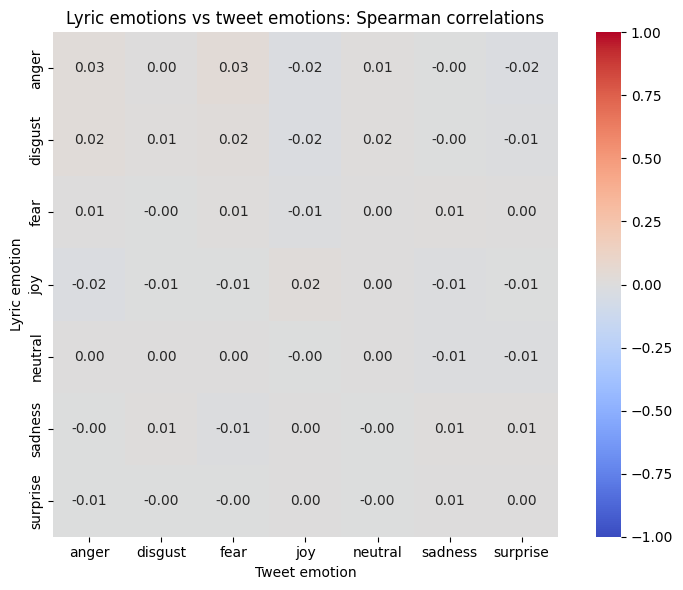

In [16]:
cross_emotion_specs = []

for lyric_emotion, lyric_col in zip(
    emotions,
    lyrics_cols,
):
    for tweet_emotion, tweet_col in zip(
        emotions,
        tweets_cols,
    ):
        cross_emotion_specs.append({
            "x": lyric_col,
            "y": tweet_col,
            "lyric_emotion": lyric_emotion,
            "tweet_emotion": tweet_emotion,
            "pair_type": (
                "matching"
                if lyric_emotion == tweet_emotion
                else "cross-emotion"
            ),
        })


cross_emotion_results = correlation_table(
    df,
    cross_emotion_specs,
)

matching_emotion_results = (
    cross_emotion_results
    .query("pair_type == 'matching'")
)


print("Matching lyric–tweet emotions:")

display(
    matching_emotion_results
    .reset_index(drop=True)
)


print(
    "Strongest lyric–tweet emotion relationships "
    "(all 49 pairs):"
)

display(
    cross_emotion_results
    .assign(
        abs_r=cross_emotion_results["spearman_r"].abs()
    )
    .sort_values(
        "abs_r",
        ascending=False,
    )
    .drop(
        columns="abs_r",
    )
    .head(15)
    .reset_index(drop=True)
)


cross_spearman = (
    cross_emotion_results
    .pivot(
        index="lyric_emotion",
        columns="tweet_emotion",
        values="spearman_r",
    )
    .reindex(
        index=emotions,
        columns=emotions,
    )
)


plt.figure(figsize=(8, 6))

sns.heatmap(
    cross_spearman,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
)

plt.title(
    "Lyric emotions vs tweet emotions: Spearman correlations"
)

plt.xlabel("Tweet emotion")
plt.ylabel("Lyric emotion")

plt.tight_layout()
plt.show()

## 2. Top-emotion label agreement

Exact agreement is supplemented with Cohen's kappa (agreement beyond chance) and bias-corrected Cramér's V (overall association between the two categorical labels).

,value
n,5.575700e+04
exact_match_rate,1.370770e-01
chance_expected_match_rate,1.343395e-01
cohen_kappa,3.162271e-03
cramers_v,1.535043e-02
chi_square_p,3.688222e-10


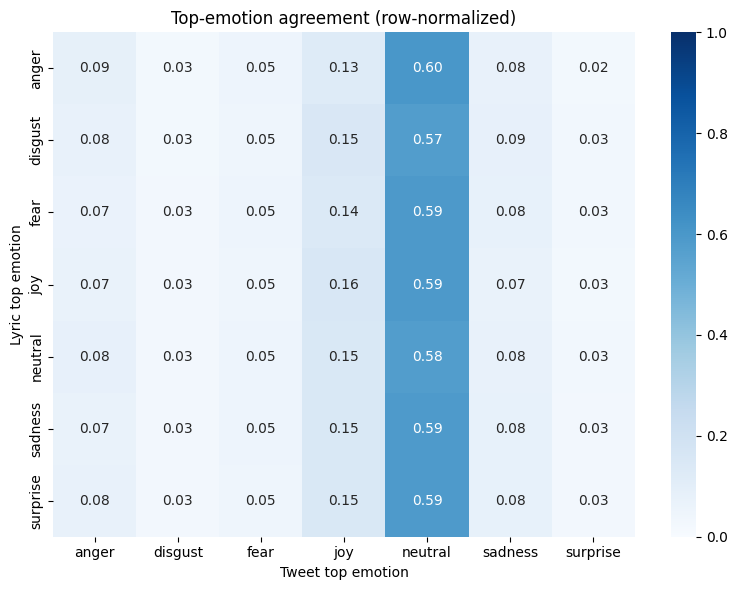

In [17]:
lyric_scores = df[lyrics_cols].apply(
    pd.to_numeric,
    errors="coerce",
)

tweet_scores = df[tweets_cols].apply(
    pd.to_numeric,
    errors="coerce",
)


valid_top = (
    lyric_scores.notna().any(axis=1)
    & tweet_scores.notna().any(axis=1)
)


lyric_top_final = (
    lyric_scores
    .loc[valid_top]
    .idxmax(axis=1)
    .str.extract(
        r"emotion_(.+)_score",
        expand=False,
    )
)

tweet_top_final = (
    tweet_scores
    .loc[valid_top]
    .idxmax(axis=1)
    .str.extract(
        r"tweet_emotion_(.+)_score",
        expand=False,
    )
)


top_table = (
    pd.crosstab(
        lyric_top_final,
        tweet_top_final,
    )
    .reindex(
        index=emotions,
        columns=emotions,
        fill_value=0,
    )
)


observed_agreement = (
    lyric_top_final == tweet_top_final
).mean()


lyric_prop = (
    lyric_top_final
    .value_counts(normalize=True)
    .reindex(
        emotions,
        fill_value=0,
    )
)

tweet_prop = (
    tweet_top_final
    .value_counts(normalize=True)
    .reindex(
        emotions,
        fill_value=0,
    )
)


chance_agreement = (
    lyric_prop * tweet_prop
).sum()


cohen_kappa = (
    observed_agreement - chance_agreement
) / (
    1 - chance_agreement
)


chi_table = top_table.loc[
    top_table.sum(axis=1) > 0,
    top_table.sum(axis=0) > 0,
]


chi2, chi2_p, _, _ = chi2_contingency(
    chi_table
)


n_top = chi_table.to_numpy().sum()

n_rows, n_cols = chi_table.shape

phi2 = chi2 / n_top


phi2_corrected = max(
    0,
    phi2
    - (
        (n_cols - 1)
        * (n_rows - 1)
    )
    / (n_top - 1),
)


rows_corrected = (
    n_rows
    - ((n_rows - 1) ** 2)
    / (n_top - 1)
)

cols_corrected = (
    n_cols
    - ((n_cols - 1) ** 2)
    / (n_top - 1)
)


cramers_denominator = min(
    rows_corrected - 1,
    cols_corrected - 1,
)


cramers_v = (
    np.sqrt(
        phi2_corrected
        / cramers_denominator
    )
    if cramers_denominator > 0
    else np.nan
)


agreement_summary = pd.Series({
    "n": n_top,
    "exact_match_rate": observed_agreement,
    "chance_expected_match_rate": chance_agreement,
    "cohen_kappa": cohen_kappa,
    "cramers_v": cramers_v,
    "chi_square_p": chi2_p,
})


display(
    agreement_summary
    .to_frame("value")
)


plt.figure(figsize=(8, 6))

sns.heatmap(
    top_table.div(
        top_table.sum(axis=1),
        axis=0,
    ),
    annot=True,
    fmt=".2f",
    cmap="Blues",
    vmin=0,
    vmax=1,
)

plt.title(
    "Top-emotion agreement (row-normalized)"
)

plt.xlabel(
    "Tweet top emotion"
)

plt.ylabel(
    "Lyric top emotion"
)

plt.tight_layout()
plt.show()

## 3. Relationships between emotions and VAD

All four source combinations are checked: lyric emotions with lyric VAD, tweet emotions with tweet VAD, and both cross-source combinations. FDR correction is applied separately to each 21-test family.

In [18]:
emotion_sources = {
    "lyric": lyrics_cols,
    "tweet": tweets_cols,
}

vad_sources = {
    "lyric": lyric_vad_cols,
    "tweet": tweet_vad_cols,
}

emotion_vad_families = []


for emotion_source, emotion_cols in emotion_sources.items():

    for vad_source, vad_cols in vad_sources.items():

        family = (
            f"{emotion_source} emotions → "
            f"{vad_source} VAD"
        )

        specs = []

        for emotion, emotion_col in zip(
            emotions,
            emotion_cols,
        ):
            for vad, vad_col in zip(
                vad_dims,
                vad_cols,
            ):
                specs.append({
                    "x": emotion_col,
                    "y": vad_col,
                    "family": family,
                    "emotion_source": emotion_source,
                    "vad_source": vad_source,
                    "emotion": emotion,
                    "vad": vad,
                })

        emotion_vad_families.append(
            correlation_table(
                df,
                specs,
            )
        )


emotion_vad_results = pd.concat(
    emotion_vad_families,
    ignore_index=True,
)


print(
    "Emotion–VAD relationships "
    "(largest |Spearman r| first within each family):"
)


for family, family_df in emotion_vad_results.groupby(
    "family",
    sort=False,
):

    print(f"\n{family}")

    display(
        family_df
        .assign(
            abs_r=family_df["spearman_r"].abs()
        )
        .sort_values(
            "abs_r",
            ascending=False,
        )
        .drop(
            columns="abs_r",
        )
        .reset_index(
            drop=True,
        )
    )

Emotion–VAD relationships (largest |Spearman r| first within each family):

lyric emotions → lyric VAD


,family,emotion_source,vad_source,emotion,vad,x_col,y_col,n,pearson_r,pearson_p,spearman_r,spearman_p,pearson_q,spearman_q,effect,fdr_significant,practically_meaningful
0,lyric emotions → lyric VAD,lyric,lyric,joy,valence,emotion_joy_score,lyric_valence,55757,0.483347,0.000000e+00,0.525715,0.000000e+00,0.000000e+00,0.000000e+00,strong,True,True
1,lyric emotions → lyric VAD,lyric,lyric,joy,dominance,emotion_joy_score,lyric_dominance,55757,0.218617,0.000000e+00,0.335957,0.000000e+00,0.000000e+00,0.000000e+00,moderate,True,True
2,lyric emotions → lyric VAD,lyric,lyric,anger,valence,emotion_anger_score,lyric_valence,55757,-0.331252,0.000000e+00,-0.320779,0.000000e+00,0.000000e+00,0.000000e+00,moderate,True,True
3,lyric emotions → lyric VAD,lyric,lyric,anger,dominance,emotion_anger_score,lyric_dominance,55757,0.273988,0.000000e+00,0.306953,0.000000e+00,0.000000e+00,0.000000e+00,moderate,True,True
4,lyric emotions → lyric VAD,lyric,lyric,disgust,valence,emotion_disgust_score,lyric_valence,55757,-0.183443,0.000000e+00,-0.287890,0.000000e+00,0.000000e+00,0.000000e+00,weak,True,True
5,lyric emotions → lyric VAD,lyric,lyric,sadness,dominance,emotion_sadness_score,lyric_dominance,55757,-0.323304,0.000000e+00,-0.279296,0.000000e+00,0.000000e+00,0.000000e+00,weak,True,True
6,lyric emotions → lyric VAD,lyric,lyric,neutral,dominance,emotion_neutral_score,lyric_dominance,55757,0.175834,0.000000e+00,0.252273,0.000000e+00,0.000000e+00,0.000000e+00,weak,True,True
7,lyric emotions → lyric VAD,lyric,lyric,disgust,dominance,emotion_disgust_score,lyric_dominance,55757,0.137234,1.591047e-232,0.222622,0.000000e+00,2.784332e-232,0.000000e+00,weak,True,True
8,lyric emotions → lyric VAD,lyric,lyric,disgust,arousal,emotion_disgust_score,lyric_arousal,55757,0.110206,3.481480e-150,0.221140,0.000000e+00,5.623928e-150,0.000000e+00,weak,True,True
9,lyric emotions → lyric VAD,lyric,lyric,neutral,valence,emotion_neutral_score,lyric_valence,55757,0.184726,0.000000e+00,0.216870,0.000000e+00,0.000000e+00,0.000000e+00,weak,True,True



lyric emotions → tweet VAD


,family,emotion_source,vad_source,emotion,vad,x_col,y_col,n,pearson_r,pearson_p,spearman_r,spearman_p,pearson_q,spearman_q,effect,fdr_significant,practically_meaningful
0,lyric emotions → tweet VAD,lyric,tweet,anger,valence,emotion_anger_score,tweet_valence,55757,-0.027802,5.165444e-11,-0.032334,2.226325e-14,1.084743e-09,4.675282e-13,negligible,True,False
1,lyric emotions → tweet VAD,lyric,tweet,anger,dominance,emotion_anger_score,tweet_dominance,55757,0.024197,1.100814e-08,0.027949,4.092739e-11,7.705696e-08,4.297376e-10,negligible,True,False
2,lyric emotions → tweet VAD,lyric,tweet,disgust,valence,emotion_disgust_score,tweet_valence,55757,-0.013404,1.549894e-03,-0.026944,1.974474e-10,3.616418e-03,1.382132e-09,negligible,True,False
3,lyric emotions → tweet VAD,lyric,tweet,joy,valence,emotion_joy_score,tweet_valence,55757,0.022405,1.215989e-07,0.026177,6.323800e-10,6.383944e-07,3.319995e-09,negligible,True,False
4,lyric emotions → tweet VAD,lyric,tweet,anger,arousal,emotion_anger_score,tweet_arousal,55757,-0.024732,5.199332e-09,-0.025362,2.103675e-09,5.459299e-08,8.835434e-09,negligible,True,False
5,lyric emotions → tweet VAD,lyric,tweet,disgust,dominance,emotion_disgust_score,tweet_dominance,55757,0.016410,1.065875e-04,0.025141,2.898056e-09,3.730562e-04,1.014320e-08,negligible,True,False
6,lyric emotions → tweet VAD,lyric,tweet,disgust,arousal,emotion_disgust_score,tweet_arousal,55757,-0.013894,1.034542e-03,-0.019519,4.039864e-06,3.103626e-03,1.211959e-05,negligible,True,False
7,lyric emotions → tweet VAD,lyric,tweet,neutral,dominance,emotion_neutral_score,tweet_dominance,55757,0.009470,2.534901e-02,0.017508,3.558213e-05,4.839356e-02,9.340310e-05,negligible,True,False
8,lyric emotions → tweet VAD,lyric,tweet,sadness,dominance,emotion_sadness_score,tweet_dominance,55757,-0.013733,1.183109e-03,-0.013785,1.133396e-03,3.105661e-03,2.644591e-03,negligible,True,False
9,lyric emotions → tweet VAD,lyric,tweet,fear,valence,emotion_fear_score,tweet_valence,55757,-0.000853,8.403585e-01,-0.010327,1.475020e-02,8.879963e-01,3.097541e-02,negligible,True,False



tweet emotions → lyric VAD


,family,emotion_source,vad_source,emotion,vad,x_col,y_col,n,pearson_r,pearson_p,spearman_r,spearman_p,pearson_q,spearman_q,effect,fdr_significant,practically_meaningful
0,tweet emotions → lyric VAD,tweet,lyric,joy,valence,tweet_emotion_joy_score,lyric_valence,55757,0.026996,1.823250e-10,0.027893,4.476312e-11,3.828825e-09,9.400255e-10,negligible,True,False
1,tweet emotions → lyric VAD,tweet,lyric,anger,valence,tweet_emotion_anger_score,lyric_valence,55757,-0.019484,4.202272e-06,-0.026434,4.299218e-10,2.941590e-05,4.514179e-09,negligible,True,False
2,tweet emotions → lyric VAD,tweet,lyric,fear,dominance,tweet_emotion_fear_score,lyric_dominance,55757,0.008533,4.392870e-02,0.025667,1.347075e-09,7.687523e-02,9.429527e-09,negligible,True,False
3,tweet emotions → lyric VAD,tweet,lyric,fear,valence,tweet_emotion_fear_score,lyric_valence,55757,-0.010049,1.764922e-02,-0.025045,3.327840e-09,3.706337e-02,1.747116e-08,negligible,True,False
4,tweet emotions → lyric VAD,tweet,lyric,sadness,dominance,tweet_emotion_sadness_score,lyric_dominance,55757,-0.016945,6.295520e-05,-0.023518,2.793439e-08,3.305148e-04,1.173244e-07,negligible,True,False
5,tweet emotions → lyric VAD,tweet,lyric,surprise,dominance,tweet_emotion_surprise_score,lyric_dominance,55757,-0.020826,8.738093e-07,-0.020555,1.209753e-06,9.174998e-06,4.234136e-06,negligible,True,False
6,tweet emotions → lyric VAD,tweet,lyric,surprise,valence,tweet_emotion_surprise_score,lyric_valence,55757,0.013244,1.764465e-03,0.019691,3.319343e-06,7.410752e-03,9.958030e-06,negligible,True,False
7,tweet emotions → lyric VAD,tweet,lyric,anger,arousal,tweet_emotion_anger_score,lyric_arousal,55757,0.010063,1.749522e-02,0.017983,2.170728e-05,3.706337e-02,5.698162e-05,negligible,True,False
8,tweet emotions → lyric VAD,tweet,lyric,fear,arousal,tweet_emotion_fear_score,lyric_arousal,55757,-0.002258,5.939957e-01,0.015454,2.630037e-04,6.929949e-01,6.136753e-04,negligible,True,False
9,tweet emotions → lyric VAD,tweet,lyric,sadness,valence,tweet_emotion_sadness_score,lyric_valence,55757,0.001940,6.468535e-01,-0.013448,1.495865e-03,7.149434e-01,3.141316e-03,negligible,True,False



tweet emotions → tweet VAD


,family,emotion_source,vad_source,emotion,vad,x_col,y_col,n,pearson_r,pearson_p,spearman_r,spearman_p,pearson_q,spearman_q,effect,fdr_significant,practically_meaningful
0,tweet emotions → tweet VAD,tweet,tweet,joy,valence,tweet_emotion_joy_score,tweet_valence,55757,0.472397,0.000000e+00,0.542182,0.000000e+00,0.000000e+00,0.000000e+00,strong,True,True
1,tweet emotions → tweet VAD,tweet,tweet,neutral,arousal,tweet_emotion_neutral_score,tweet_arousal,55757,-0.425986,0.000000e+00,-0.439846,0.000000e+00,0.000000e+00,0.000000e+00,moderate,True,True
2,tweet emotions → tweet VAD,tweet,tweet,anger,valence,tweet_emotion_anger_score,tweet_valence,55757,-0.313546,0.000000e+00,-0.282167,0.000000e+00,0.000000e+00,0.000000e+00,weak,True,True
3,tweet emotions → tweet VAD,tweet,tweet,sadness,valence,tweet_emotion_sadness_score,tweet_valence,55757,-0.299934,0.000000e+00,-0.240586,0.000000e+00,0.000000e+00,0.000000e+00,weak,True,True
4,tweet emotions → tweet VAD,tweet,tweet,fear,valence,tweet_emotion_fear_score,tweet_valence,55757,-0.098306,9.176949e-120,-0.231473,0.000000e+00,1.376542e-119,0.000000e+00,weak,True,True
5,tweet emotions → tweet VAD,tweet,tweet,disgust,valence,tweet_emotion_disgust_score,tweet_valence,55757,-0.197080,0.000000e+00,-0.221802,0.000000e+00,0.000000e+00,0.000000e+00,weak,True,True
6,tweet emotions → tweet VAD,tweet,tweet,sadness,dominance,tweet_emotion_sadness_score,tweet_dominance,55757,-0.203390,0.000000e+00,-0.213208,0.000000e+00,0.000000e+00,0.000000e+00,weak,True,True
7,tweet emotions → tweet VAD,tweet,tweet,joy,dominance,tweet_emotion_joy_score,tweet_dominance,55757,0.179641,0.000000e+00,0.140907,3.789603e-245,0.000000e+00,9.947709e-245,weak,True,True
8,tweet emotions → tweet VAD,tweet,tweet,surprise,valence,tweet_emotion_surprise_score,tweet_valence,55757,0.055238,6.115866e-39,0.140243,7.710858e-243,7.554894e-39,1.799200e-242,weak,True,True
9,tweet emotions → tweet VAD,tweet,tweet,neutral,dominance,tweet_emotion_neutral_score,tweet_dominance,55757,-0.105895,9.372554e-139,-0.138409,1.596164e-236,1.514028e-138,3.351944e-236,weak,True,True


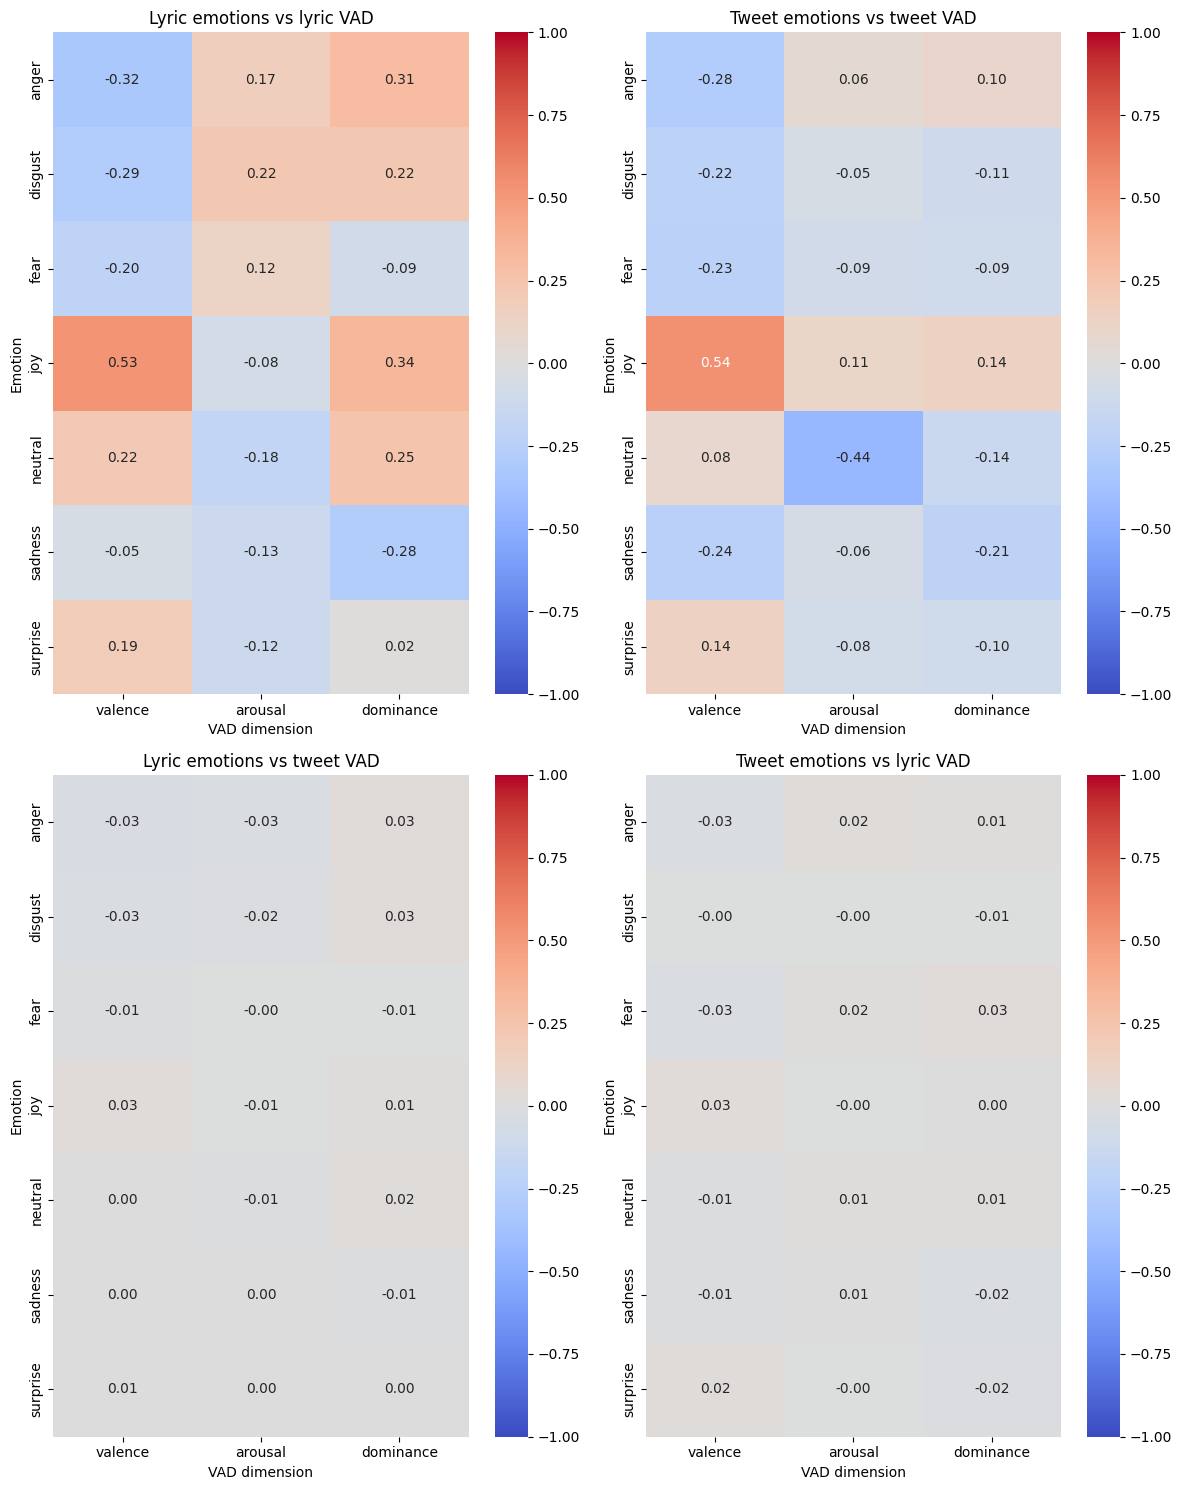

In [19]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 15),
)


for ax, (
    (emotion_source, emotion_cols),
    (vad_source, vad_cols),
) in zip(

    axes.flat,

    [
        (
            ("lyric", lyrics_cols),
            ("lyric", lyric_vad_cols),
        ),
        (
            ("tweet", tweets_cols),
            ("tweet", tweet_vad_cols),
        ),
        (
            ("lyric", lyrics_cols),
            ("tweet", tweet_vad_cols),
        ),
        (
            ("tweet", tweets_cols),
            ("lyric", lyric_vad_cols),
        ),
    ],
):

    matrix = pd.DataFrame(
        [
            [
                df[e_col].corr(
                    df[v_col],
                    method="spearman",
                )
                for v_col in vad_cols
            ]
            for e_col in emotion_cols
        ],
        index=emotions,
        columns=vad_dims,
    )


    sns.heatmap(
        matrix,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        vmin=-1,
        vmax=1,
        ax=ax,
    )


    ax.set_title(
        f"{emotion_source.title()} emotions "
        f"vs {vad_source} VAD"
    )

    ax.set_xlabel(
        "VAD dimension"
    )

    ax.set_ylabel(
        "Emotion"
    )


plt.tight_layout()
plt.show()

## 4. Lyric–tweet VAD alignment

This checks whether VAD dimensions agree across lyrics and tweets, both for matching dimensions and all cross-dimension pairs.

,lyric_vad,tweet_vad,pair_type,x_col,y_col,n,pearson_r,pearson_p,spearman_r,spearman_p,pearson_q,spearman_q,effect,fdr_significant,practically_meaningful
0,valence,valence,matching,lyric_valence,tweet_valence,55757,0.033167,4.738324e-15,0.047813,1.371085e-29,4.264491e-14,1.233976e-28,negligible,True,False
1,dominance,dominance,matching,lyric_dominance,tweet_dominance,55757,0.028576,1.489976e-11,0.033609,2.050888e-15,6.704893e-11,9.228994e-15,negligible,True,False
2,arousal,arousal,matching,lyric_arousal,tweet_arousal,55757,-0.000341,9.358483e-01,-0.006068,1.519095e-01,9.358483e-01,1.953122e-01,negligible,False,False
3,dominance,arousal,cross-dimension,lyric_dominance,tweet_arousal,55757,-0.014293,7.377519e-04,-0.018939,7.738061e-06,1.327953e-03,2.321418e-05,negligible,True,False
4,valence,arousal,cross-dimension,lyric_valence,tweet_arousal,55757,0.021007,7.021007e-07,0.018089,1.941625e-05,2.106302e-06,4.368656e-05,negligible,True,False
5,arousal,dominance,cross-dimension,lyric_arousal,tweet_dominance,55757,0.014425,6.582989e-04,0.014588,5.714919e-04,1.327953e-03,1.028685e-03,negligible,True,False
6,valence,dominance,cross-dimension,lyric_valence,tweet_dominance,55757,-0.010925,9.889460e-03,-0.011300,7.622740e-03,1.483419e-02,1.143411e-02,negligible,True,False
7,dominance,valence,cross-dimension,lyric_dominance,tweet_valence,55757,-0.007243,8.722442e-02,-0.000137,9.742423e-01,1.121457e-01,9.789063e-01,negligible,False,False
8,arousal,valence,cross-dimension,lyric_arousal,tweet_valence,55757,-0.000437,9.177509e-01,0.000112,9.789063e-01,9.358483e-01,9.789063e-01,negligible,False,False


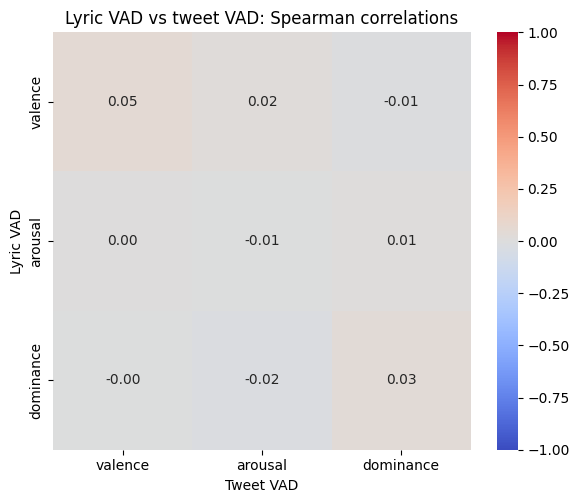

In [20]:
cross_vad_specs = []


for lyric_vad, lyric_col in zip(
    vad_dims,
    lyric_vad_cols,
):

    for tweet_vad, tweet_col in zip(
        vad_dims,
        tweet_vad_cols,
    ):

        cross_vad_specs.append({
            "x": lyric_col,
            "y": tweet_col,
            "lyric_vad": lyric_vad,
            "tweet_vad": tweet_vad,
            "pair_type": (
                "matching"
                if lyric_vad == tweet_vad
                else "cross-dimension"
            ),
        })


cross_vad_results = correlation_table(
    df,
    cross_vad_specs,
)


display(
    cross_vad_results
    .assign(
        abs_r=cross_vad_results[
            "spearman_r"
        ].abs()
    )
    .sort_values(
        [
            "pair_type",
            "abs_r",
        ],
        ascending=[
            False,
            False,
        ],
    )
    .drop(
        columns="abs_r",
    )
    .reset_index(
        drop=True,
    )
)


cross_vad_matrix = (
    cross_vad_results
    .pivot(
        index="lyric_vad",
        columns="tweet_vad",
        values="spearman_r",
    )
    .reindex(
        index=vad_dims,
        columns=vad_dims,
    )
)


plt.figure(
    figsize=(6, 5)
)


sns.heatmap(
    cross_vad_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
)


plt.title(
    "Lyric VAD vs tweet VAD: "
    "Spearman correlations"
)

plt.xlabel(
    "Tweet VAD"
)

plt.ylabel(
    "Lyric VAD"
)

plt.tight_layout()
plt.show()

## 5. Robustness by disorder group

Matching lyric–tweet emotions and matching lyric–tweet VAD dimensions are recalculated separately within each disorder group. This checks whether an overall association is driven by differences between groups.

In [21]:
if "disorder" not in df.columns:
    raise KeyError(
        "Column 'disorder' is required "
        "for the group robustness check."
    )


emotion_group_results = []
vad_group_results = []


for group, group_df in df.groupby(
    "disorder",
    dropna=False,
):

    emotion_specs = [
        {
            "x": lyric_col,
            "y": tweet_col,
            "emotion": emotion,
        }
        for emotion, lyric_col, tweet_col
        in zip(
            emotions,
            lyrics_cols,
            tweets_cols,
        )
    ]


    group_emotions = correlation_table(
        group_df,
        emotion_specs,
    )

    group_emotions.insert(
        0,
        "disorder",
        group,
    )

    emotion_group_results.append(
        group_emotions
    )


    vad_specs = [
        {
            "x": lyric_col,
            "y": tweet_col,
            "vad": vad,
        }
        for vad, lyric_col, tweet_col
        in zip(
            vad_dims,
            lyric_vad_cols,
            tweet_vad_cols,
        )
    ]


    group_vad = correlation_table(
        group_df,
        vad_specs,
    )

    group_vad.insert(
        0,
        "disorder",
        group,
    )

    vad_group_results.append(
        group_vad
    )


emotion_group_results = pd.concat(
    emotion_group_results,
    ignore_index=True,
)

vad_group_results = pd.concat(
    vad_group_results,
    ignore_index=True,
)


print(
    "Matching lyric–tweet emotion "
    "correlations by disorder group:"
)

display(
    emotion_group_results
)


print(
    "Matching lyric–tweet VAD "
    "correlations by disorder group:"
)

display(
    vad_group_results
)

Matching lyric–tweet emotion correlations by disorder group:


,disorder,emotion,x_col,y_col,n,pearson_r,pearson_p,spearman_r,spearman_p,pearson_q,spearman_q,effect,fdr_significant,practically_meaningful
0,control,anger,emotion_anger_score,tweet_emotion_anger_score,48233,0.021712,0.000002,0.027803,1.014739e-09,0.000013,7.103174e-09,negligible,True,False
1,control,disgust,emotion_disgust_score,tweet_emotion_disgust_score,48233,0.000094,0.983548,0.012288,6.958352e-03,0.983548,1.623615e-02,negligible,True,False
2,control,fear,emotion_fear_score,tweet_emotion_fear_score,48233,0.000214,0.962503,0.011075,1.499915e-02,0.983548,2.099881e-02,negligible,True,False
3,control,joy,emotion_joy_score,tweet_emotion_joy_score,48233,0.020138,0.000010,0.024834,4.903089e-08,0.000034,1.716081e-07,negligible,True,False
4,control,neutral,emotion_neutral_score,tweet_emotion_neutral_score,48233,-0.006888,0.130358,0.001620,7.220164e-01,0.304168,7.220164e-01,negligible,False,False
5,control,sadness,emotion_sadness_score,tweet_emotion_sadness_score,48233,0.006043,0.184449,0.011351,1.266963e-02,0.322785,2.099881e-02,negligible,True,False
6,control,surprise,emotion_surprise_score,tweet_emotion_surprise_score,48233,0.005144,0.258643,0.004033,3.757430e-01,0.362101,4.383668e-01,negligible,False,False
7,depression,anger,emotion_anger_score,tweet_emotion_anger_score,7524,0.013554,0.239767,0.019392,9.258236e-02,0.515794,6.480765e-01,negligible,False,False
8,depression,disgust,emotion_disgust_score,tweet_emotion_disgust_score,7524,0.000868,0.939990,-0.006933,5.476673e-01,0.939990,9.654010e-01,negligible,False,False
9,depression,fear,emotion_fear_score,tweet_emotion_fear_score,7524,0.003875,0.736802,-0.000500,9.654010e-01,0.859602,9.654010e-01,negligible,False,False


Matching lyric–tweet VAD correlations by disorder group:


,disorder,vad,x_col,y_col,n,pearson_r,pearson_p,spearman_r,spearman_p,pearson_q,spearman_q,effect,fdr_significant,practically_meaningful
0,control,valence,lyric_valence,tweet_valence,48233,0.037992,7.020915e-17,0.052070,2.543458e-30,2.106275e-16,7.630373e-30,negligible,True,False
1,control,arousal,lyric_arousal,tweet_arousal,48233,-0.002599,5.680805e-01,-0.008451,6.344209e-02,5.680805e-01,6.344209e-02,negligible,False,False
2,control,dominance,lyric_dominance,tweet_dominance,48233,0.026589,5.206812e-09,0.033268,2.706807e-13,7.810219e-09,4.060211e-13,negligible,True,False
3,depression,valence,lyric_valence,tweet_valence,7524,0.007419,5.199657e-01,0.020188,7.995056e-02,5.199657e-01,1.199258e-01,negligible,False,False
4,depression,arousal,lyric_arousal,tweet_arousal,7524,0.013882,2.286070e-01,0.007356,5.235125e-01,3.429104e-01,5.235125e-01,negligible,False,False
5,depression,dominance,lyric_dominance,tweet_dominance,7524,0.021757,5.913814e-02,0.028196,1.445250e-02,1.774144e-01,4.335749e-02,negligible,True,False


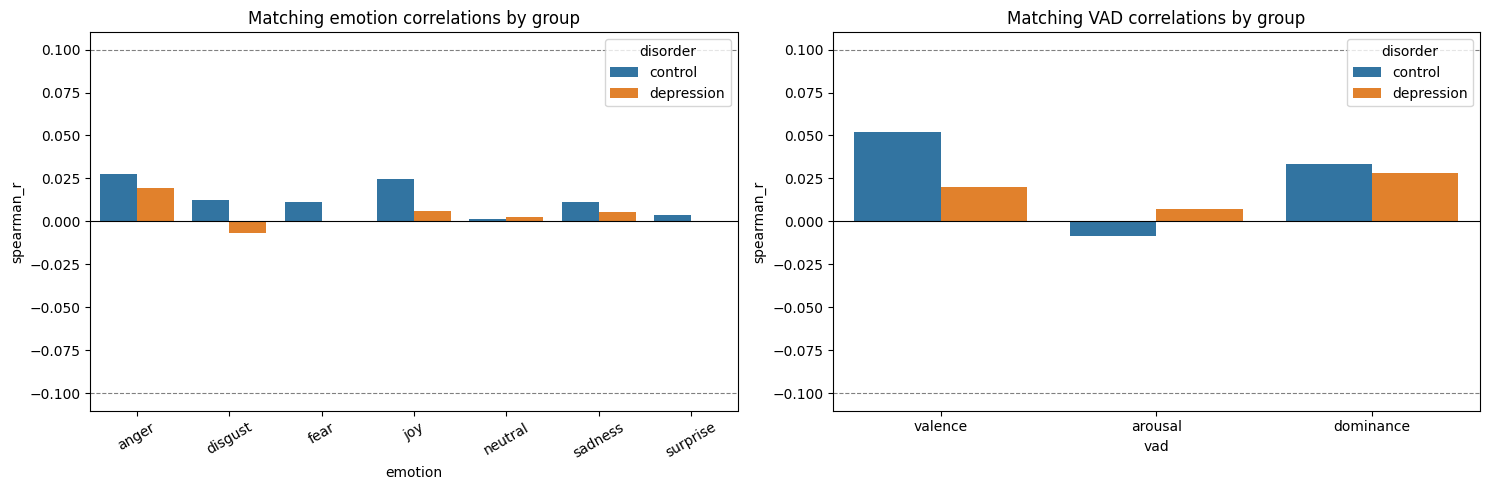

In [22]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5),
)


sns.barplot(
    data=emotion_group_results,
    x="emotion",
    y="spearman_r",
    hue="disorder",
    ax=axes[0],
)

axes[0].axhline(
    0,
    color="black",
    linewidth=0.8,
)

axes[0].axhline(
    0.10,
    color="grey",
    linestyle="--",
    linewidth=0.8,
)

axes[0].axhline(
    -0.10,
    color="grey",
    linestyle="--",
    linewidth=0.8,
)

axes[0].set_title(
    "Matching emotion correlations by group"
)

axes[0].tick_params(
    axis="x",
    rotation=30,
)


sns.barplot(
    data=vad_group_results,
    x="vad",
    y="spearman_r",
    hue="disorder",
    ax=axes[1],
)

axes[1].axhline(
    0,
    color="black",
    linewidth=0.8,
)

axes[1].axhline(
    0.10,
    color="grey",
    linestyle="--",
    linewidth=0.8,
)

axes[1].axhline(
    -0.10,
    color="grey",
    linestyle="--",
    linewidth=0.8,
)

axes[1].set_title(
    "Matching VAD correlations by group"
)


plt.tight_layout()
plt.show()

## Reading the final output

Use `spearman_r` as the primary association estimate and `spearman_q < 0.05` for FDR-corrected statistical evidence. Treat an association as substantively notable only when `practically_meaningful` is `True` as well. Compare the group-specific estimates with the overall estimates; a relationship that reverses or disappears within groups may be confounded by group membership. Cohen's kappa near zero means that top-emotion agreement is no better than chance, even if the chi-square test is significant.